<div class="alert alert-info" style="background-color:#001b79; color:white; padding:0px 10px; border-radius:5px;"><h2 style='margin:10px 5px'>K MEAN CLUSTER </h2>
</div>

## Module 9 - Unsupervised Learning



<div class="alert alert-info" style="background-color:#001b32; color:white; padding:0px 10px; border-radius:5px;"><h2 style='margin:10px 5px'>Problem  Statement </h2>
</div>

##  Case Study

##  Objective:
    •Use k-means clustering for image segmentation and to identify dominant color in the image.
    
##  Question:
    1.Open and display the image “dog.jpeg”. Convert the image in to numpy array,so that i can be   used in further processing.
    [Hint:Use PIL module from python]
    
    2. Find out the dimensions of the image and convert it in to a two-dimensional array. 
    
    3.Use kmeans clustering with k set to 3 and cluster the image.
    [Hint: Refer to k-means module of scikit learn]
    
    4. Predict the cluster label of every pixel in the image and plot it back as an image.
    
    5. Find out the three dominant color in the image.
    [Hint: The cluster centers should correspond to three dominant colors]


##  1. Import all Librariy

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from PIL import Image


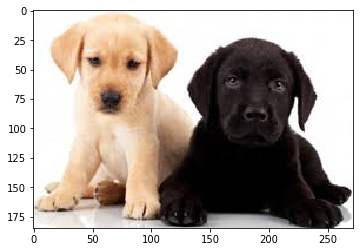

In [7]:
# data set
dogdata = Image.open(r"..\Dataset\dogs.jpeg")

dogdata.show()  #This dispays image in another window

plt.imshow(dogdata)  #This dispays image in notepad
dogdata.rotate(45).show()  #Image rotate with 45 degree and shows in another window

## 2. Image Exploration

In [10]:
#Convert it to numpy array

dog_array = np.asarray(dogdata)
print(type(dog_array))
print((dog_array))


<class 'numpy.ndarray'>
[[[240 240 240]
  [255 255 255]
  [255 255 255]
  ...
  [254 254 254]
  [254 254 254]
  [254 254 254]]

 [[240 240 240]
  [255 255 255]
  [255 255 255]
  ...
  [254 254 254]
  [254 254 254]
  [254 254 254]]

 [[240 240 240]
  [255 255 255]
  [255 255 255]
  ...
  [254 254 254]
  [254 254 254]
  [254 254 254]]

 ...

 [[252 248 249]
  [254 250 251]
  [255 253 254]
  ...
  [255 255 255]
  [255 255 255]
  [255 255 255]]

 [[247 245 246]
  [250 248 249]
  [255 253 254]
  ...
  [255 255 255]
  [252 252 252]
  [244 244 244]]

 [[253 251 254]
  [253 251 254]
  [253 251 252]
  ...
  [254 254 254]
  [254 254 254]
  [254 254 254]]]


<class 'PIL.Image.Image'>


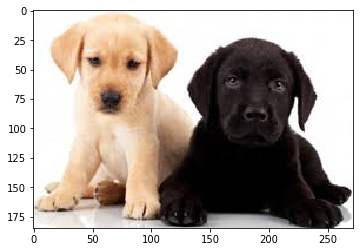

In [11]:
#Convert  numpy array to image back

dog_new = Image.fromarray(np.uint8(dog_array))
print(type(dog_new))
plt.imshow(dog_new)

In [12]:
#Find current Dimension
print("Dimension of array: ", dog_array.shape)
print("Dimension of array: ", dog_array.ndim)

x, y, z = dog_array.shape
print("Image shape : " ,x, y, z)
#Currently its 3 dimesion aray

Dimension of array:  (185, 272, 3)
Dimension of array:  3
Image shape :  185 272 3


In [13]:
#Convert 3d to 2 d array
# Load Image and transform to a 2D numpy array.
w, h, d = original_shape = tuple(dog_array.shape)
print("W: %s, h: %s, d: %s" %(w,h,d))
assert d == 3

# dog_2d = dog_array.reshape((185*272,3))
dog_2d = np.reshape(dog_array, (w * h, d))
print("Dimension of array: ",dog_2d.ndim)
print("Shape of array: ",dog_2d.shape)

W: 185, h: 272, d: 3
Dimension of array:  2
Shape of array:  (50320, 3)


## 3. Building Machine Learning KMean Cluster

In [16]:
#Use kmeans clustering with k set to 3 and cluster the image.

from sklearn.cluster import KMeans

kmean = KMeans(n_clusters=3, init='k-means++')

# Get labels for all points
y_means = kmean.fit_predict(dog_2d)
y_means  # cluster IDs from 0 to 2

cluster_centers = kmean.cluster_centers_
cluster_labels = kmean.labels_   # This also same as y_means
print("Cluster Labels :\n " ,cluster_labels)
print("\n Cluster center :\n " ,cluster_centers)
# Here it gives 3 ponts in centroid

Cluster Labels :
  [1 1 1 ... 1 1 1]

 Cluster center :
  [[210.65606557 174.85483607 143.73803279]
 [251.4871407  247.6867877  243.16348966]
 [ 29.52558775  21.59168945  20.48217605]]


## 4. Model Evaluation with Visualization

-  Once the clusters are formed, we can recreate the image with the cluster centers and labels to display the image with grouped patterns.

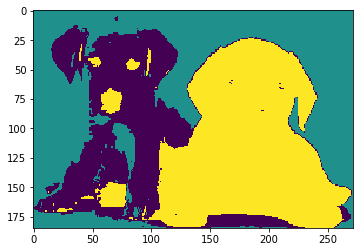

In [17]:
y_means_reshape = y_means.reshape((185,272))
plt.imshow(y_means_reshape)

### 4.1 Model Evaluation with Visualization -  Edu further detail

    5. Find out the three dominant color in the image.
    [Hint: The cluster centers should correspond to three dominant colors]

In [20]:
# 3 cluster center points, converted to integer and list of 3 array values
print("Cluster Centers :\n " , cluster_centers)
centers = [centers.astype(int) for centers in kmean.cluster_centers_]
print("\n Cluster Centers convered to Integer:\n " , centers )

Cluster Centers :
  [[210.65606557 174.85483607 143.73803279]
 [251.4871407  247.6867877  243.16348966]
 [ 29.52558775  21.59168945  20.48217605]]

 Cluster Centers convered to Integer:
  [array([210, 174, 143]), array([251, 247, 243]), array([29, 21, 20])]


In [22]:
#create 3 dim array with zeros
blob = np.ones((100,100,3))
print(blob.shape)
print(blob.ndim)

(100, 100, 3)
3


In [23]:
blob1 = blob * centers[0]
blob1

array([[[210., 174., 143.],
        [210., 174., 143.],
        [210., 174., 143.],
        ...,
        [210., 174., 143.],
        [210., 174., 143.],
        [210., 174., 143.]],

       [[210., 174., 143.],
        [210., 174., 143.],
        [210., 174., 143.],
        ...,
        [210., 174., 143.],
        [210., 174., 143.],
        [210., 174., 143.]],

       [[210., 174., 143.],
        [210., 174., 143.],
        [210., 174., 143.],
        ...,
        [210., 174., 143.],
        [210., 174., 143.],
        [210., 174., 143.]],

       ...,

       [[210., 174., 143.],
        [210., 174., 143.],
        [210., 174., 143.],
        ...,
        [210., 174., 143.],
        [210., 174., 143.],
        [210., 174., 143.]],

       [[210., 174., 143.],
        [210., 174., 143.],
        [210., 174., 143.],
        ...,
        [210., 174., 143.],
        [210., 174., 143.],
        [210., 174., 143.]],

       [[210., 174., 143.],
        [210., 174., 143.],
        [210., 1

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


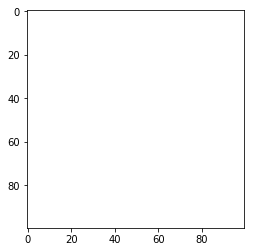

In [24]:
#Only me getting this error in anaconda, but in edu sol some color graph is diplayed.
plt.imshow(blob1)

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


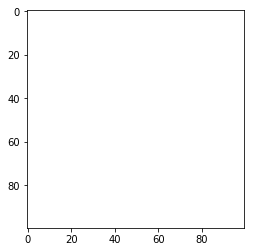

In [25]:
#Only me getting this error in anaconda, but in edu sol some color graph is diplayed.
blob2 = blob * centers[1]
plt.imshow(blob2)

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


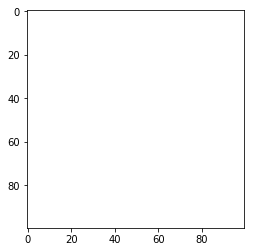

In [26]:
#Only me getting this error in anaconda, but in edu sol some color graph is diplayed.
blob3 = blob * centers[2]
plt.imshow(blob3)

## 4. Below are not part of Q
Its just extra code to a "quantized image using a random codebook"
reducing the number of colors required to show the image from 96,615 unique colors to 64, while preserving the overall appearance quality.


"""
In this example, pixels are represented in a 3D-space and K-means is used to find 64 color clusters. In the image processing literature, the codebook obtained from K-means (the cluster centers) is called the color palette. Using a single byte, up to 256 colors can be addressed, whereas an RGB encoding requires 3 bytes per pixel. The GIF file format, for example, uses such a palette.
"""

In [27]:
from sklearn.utils import shuffle
from sklearn.metrics import pairwise_distances_argmin
n_colors = 64

codebook_random = shuffle(dog_2d, random_state=0)[:n_colors]
print("Predicting color indices on the full image (random)")
labels_random = pairwise_distances_argmin(codebook_random,
                                          dog_2d,
                                          axis=0)



def recreate_image(codebook, labels, w, h):
    """Recreate the (compressed) image from the code book & labels"""
    d = codebook.shape[1]
    image = np.zeros((w, h, d))
    label_idx = 0
    for i in range(w):
        for j in range(h):
            image[i][j] = codebook[labels[label_idx]]
            label_idx += 1
    return image

Predicting color indices on the full image (random)


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


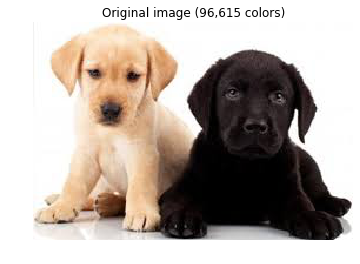

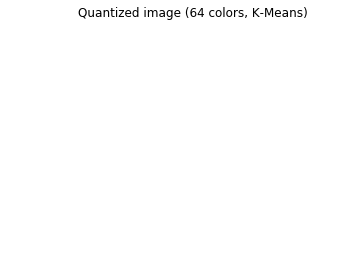

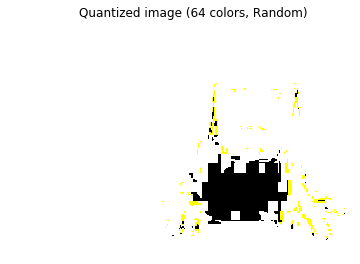

In [28]:
# Display all results, alongside original image
plt.figure(1)
plt.clf()
plt.axis('off')
plt.title('Original image (96,615 colors)')
plt.imshow(dogdata)

plt.figure(2)
plt.clf()
plt.axis('off')
plt.title('Quantized image (64 colors, K-Means)')
plt.imshow(recreate_image(kmean.cluster_centers_, y_means, w, h))

plt.figure(3)
plt.clf()
plt.axis('off')
plt.title('Quantized image (64 colors, Random)')
plt.imshow(recreate_image(codebook_random, labels_random, w, h))
plt.show()

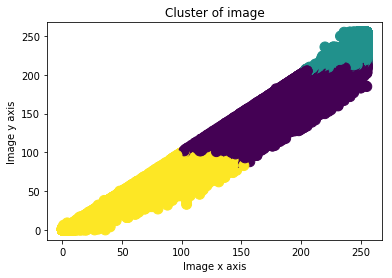

In [29]:

plt.scatter(dog_2d[:, 0], dog_2d[:, 1],  s=100, c=y_means)
     
"""
plt.scatter(dog_2d[y_means == 0, 0], dog_2d[y_means == 0, 1],
           s=100, c='red', label='Cluster 1')
plt.scatter(dog_2d[y_means == 1, 0], dog_2d[y_means == 1, 1],
           s=100, c='blue', label='Cluster 2')
plt.scatter(dog_2d[y_means == 2, 0], dog_2d[y_means == 2, 1],
           s=100, c='green', label='Cluster 3')
"""
plt.title("Cluster of image")
plt.xlabel("Image x axis")
plt.ylabel("Image y axis")
#plt.legend()
plt.show()